# FIGS1: Parallel-Coordinate Representation of Hyperparameter Optimization

This notebook regenerates Supplementary Figure 1 from the packaged data archive `FIGS1.zip`.
The archive must be in the same folder as this notebook. No synthetic or placeholder data are generated.

Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIGS1.svg
Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIGS1.pdf


Saved /Users/serhiibahdasariants/Desktop/ANNet/FIGURES/DATA AND SCRIPTS/FIGS1.png


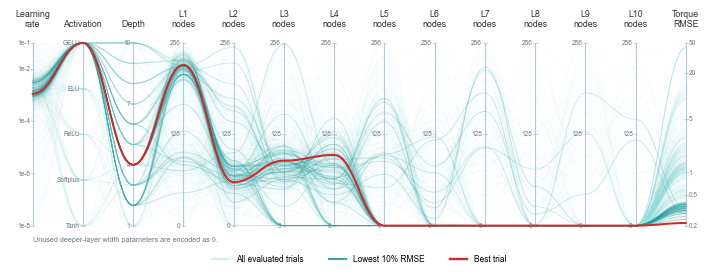

Data provenance:
  no_fake_data_generated = True
  raw trials = 500
  plotted trials = 500
  top decile trials = 50
  best trial = 220
  best RMSE = 0.216387 Nm


In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Load packaged data. FIGS1.zip must be in the same folder as this notebook.
# -----------------------------------------------------------------------------
DATA_ARCHIVE = Path("FIGS1.zip")
if not DATA_ARCHIVE.exists():
    DATA_ARCHIVE = Path("FIGS1")
if not DATA_ARCHIVE.exists():
    raise FileNotFoundError(
        "Could not find FIGS1.zip or FIGS1 in the current folder. "
        "Place the data archive in the same folder as FIGS1.ipynb."
    )

with zipfile.ZipFile(DATA_ARCHIVE) as archive:
    raw_trials = pd.read_csv(archive.open("figs1_optuna_trials_raw.csv"))
    trials = pd.read_csv(archive.open("figs1_parallel_coordinates_trials.csv"))
    axis_definitions = json.load(archive.open("figs1_axis_definitions.json"))
    best_trial = json.load(archive.open("figs1_best_trial.json"))
    metadata = json.load(archive.open("figs1_metadata.json"))

# -----------------------------------------------------------------------------
# Style and helpers.
# -----------------------------------------------------------------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.55,
    "xtick.major.width": 0.55,
    "ytick.major.width": 0.55,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.dpi": 600,
})

PALE_CYAN = "#8EDFE0"
TEAL = "#209E9B"
RED = "#D62728"
AXIS_COLOR = "#B7C9D9"
TICK_COLOR = "#6F7780"
LABEL_COLOR = "#333333"


def log_norm(values, vmin, vmax):
    values = np.asarray(values, dtype=float)
    values = np.clip(values, vmin, vmax)
    denom = np.log10(vmax) - np.log10(vmin)
    return (np.log10(values) - np.log10(vmin)) / denom


def linear_norm(values, vmin, vmax):
    values = np.asarray(values, dtype=float)
    return (values - vmin) / (vmax - vmin)


def normalize_dimension(values, definition):
    if definition["scale"] == "log10":
        return log_norm(values, definition["minimum"], definition["maximum"])
    if definition["scale"] == "linear":
        return linear_norm(values, definition["minimum"], definition["maximum"])
    if definition["scale"] == "categorical":
        ticks = np.asarray(definition["ticks"], dtype=float)
        return linear_norm(values, float(ticks.min()), float(ticks.max()))
    raise ValueError(f"Unknown scale: {definition['scale']}")


def normalize_tick(value, definition):
    return float(normalize_dimension([value], definition)[0])


def add_smooth_polyline(ax, xs, ys, color, alpha, linewidth, zorder):
    vertices = [(xs[0], ys[0])]
    codes = [MplPath.MOVETO]
    for i in range(len(xs) - 1):
        x0, y0 = xs[i], ys[i]
        x1, y1 = xs[i + 1], ys[i + 1]
        dx = x1 - x0
        vertices.extend([
            (x0 + 0.42 * dx, y0),
            (x1 - 0.42 * dx, y1),
            (x1, y1),
        ])
        codes.extend([MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4])
    patch = PathPatch(
        MplPath(vertices, codes),
        facecolor="none",
        edgecolor=color,
        alpha=alpha,
        linewidth=linewidth,
        zorder=zorder,
        capstyle="round",
        joinstyle="round",
        rasterized=False,
    )
    ax.add_patch(patch)

# Build the normalized coordinates used in the parallel-coordinate plot.
x_positions = np.arange(len(axis_definitions), dtype=float)
y_columns = []
for definition in axis_definitions:
    y_columns.append(normalize_dimension(trials[definition["column"]].to_numpy(), definition))
y_matrix = np.vstack(y_columns).T

best_mask = trials["best_trial"].astype(bool).to_numpy()
if best_mask.sum() != 1:
    raise ValueError("Expected exactly one best trial in figs1_parallel_coordinates_trials.csv")
best_idx = int(np.flatnonzero(best_mask)[0])
top_decile_mask = trials["top_decile_rmse"].astype(bool).to_numpy()

# -----------------------------------------------------------------------------
# Plot Supplementary Figure 1.
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.20, 3.25), constrained_layout=False)
fig.subplots_adjust(left=0.022, right=0.992, top=0.885, bottom=0.205)
ax.set_xlim(-0.45, len(axis_definitions) - 0.55)
ax.set_ylim(-0.08, 1.13)
ax.axis("off")

for x, definition in zip(x_positions, axis_definitions):
    label = definition["label"].replace(" ", "\n") if definition["label"] in {"Learning rate", "Torque RMSE"} else definition["label"].replace(" nodes", "\nnodes")
    ax.plot([x, x], [0, 1], color=AXIS_COLOR, linewidth=0.85, zorder=1)
    ax.text(x, 1.075, label, ha="center", va="bottom", color=LABEL_COLOR, fontsize=6.4)
    for tick, ticklabel in zip(definition["ticks"], definition["ticklabels"]):
        y = normalize_tick(tick, definition)
        if 0 <= y <= 1:
            ax.plot([x - 0.035, x + 0.035], [y, y], color=AXIS_COLOR, linewidth=0.55, zorder=2)
            horizontal_offset = -0.055 if x < len(axis_definitions) - 1 else 0.055
            align = "right" if x < len(axis_definitions) - 1 else "left"
            ax.text(x + horizontal_offset, y, str(ticklabel), ha=align, va="center",
                    color=TICK_COLOR, fontsize=4.7)

# Draw higher-error trials first, then the top decile, then the best trial.
draw_order = trials.sort_values("RMSE", ascending=False).index.to_numpy()
index_to_position = {idx: pos for pos, idx in enumerate(trials.index)}
for row_index in draw_order:
    pos = index_to_position[row_index]
    if pos == best_idx:
        continue
    if bool(top_decile_mask[pos]):
        color, alpha, linewidth, zorder = TEAL, 0.22, 0.72, 5
    else:
        color, alpha, linewidth, zorder = PALE_CYAN, 0.075, 0.42, 3
    add_smooth_polyline(ax, x_positions, y_matrix[pos], color, alpha, linewidth, zorder)

add_smooth_polyline(ax, x_positions, y_matrix[best_idx], RED, 1.0, 1.45, 9)

legend_handles = [
    Line2D([0], [0], color=PALE_CYAN, lw=1.2, alpha=0.55, label="All evaluated trials"),
    Line2D([0], [0], color=TEAL, lw=1.5, alpha=0.9, label="Lowest 10% RMSE"),
    Line2D([0], [0], color=RED, lw=1.7, label="Best trial"),
]
ax.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.14),
          ncol=3, frameon=False, handlelength=2.1, columnspacing=3.0)
ax.text(0, -0.060, "Unused deeper-layer width parameters are encoded as 0.",
        ha="left", va="top", color=TICK_COLOR, fontsize=5.2)

for ext in ["svg", "pdf", "png"]:
    path = Path(f"FIGS1.{ext}")
    if ext == "png":
        fig.savefig(path, dpi=600, bbox_inches="tight", pad_inches=0.025, facecolor="white")
    else:
        fig.savefig(path, bbox_inches="tight", pad_inches=0.025, facecolor="white")
    print(f"Saved {path.resolve()}")

plt.show()

print("Data provenance:")
print(f"  no_fake_data_generated = {metadata['no_fake_data_generated']}")
print(f"  raw trials = {metadata['num_trials_raw']}")
print(f"  plotted trials = {metadata['num_trials_plotted']}")
print(f"  top decile trials = {metadata['top_decile_count']}")
print(f"  best trial = {best_trial['trial_number']}")
print(f"  best RMSE = {best_trial['validation_torque_rmse_nm']:.6f} Nm")